In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, confusion_matrix, classification_report, recall_score

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC 
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
df = pd.read_csv('datasets/twitter_sentimentsnalysis.csv',
                names=['id', 'company', 'sentiment', 'text'])

In [31]:
def introduction_to_df(dataframe):
    print(dataframe.head(5));print('\n')
    print(dataframe.columns);print('\n')
    print(dataframe.shape);print('\n')
    print(dataframe.isnull().sum());print('\n')

In [32]:
introduction_to_dataframe = introduction_to_df(df)
print(introduction_to_df)

     id      company sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


Index(['id', 'company', 'sentiment', 'text'], dtype='object')


(74682, 4)


id             0
company        0
sentiment      0
text         686
dtype: int64


<function introduction_to_df at 0x7ec88226d760>


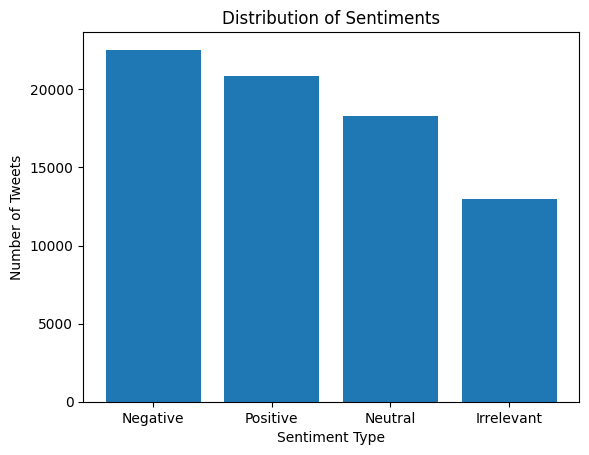

In [33]:
sentiment_counts = df['sentiment'].value_counts()

plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment Type')
plt.ylabel('Number of Tweets')
plt.show()

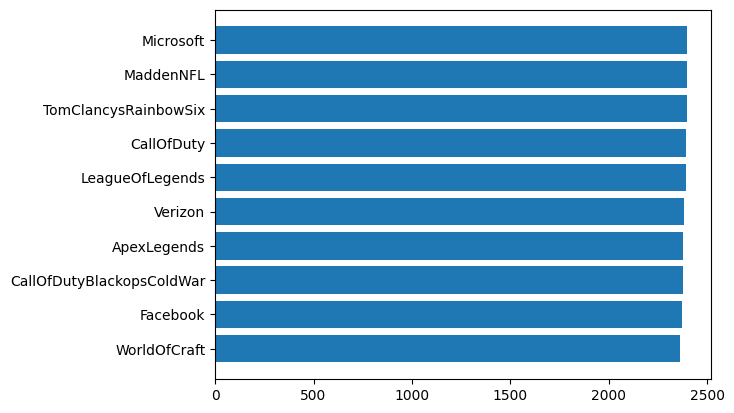

In [34]:
top_games = df['company'].value_counts().head(10).sort_values(ascending=True)
plt.barh(top_games.index, top_games.values)
plt.show()

In [62]:
df = df.dropna(subset=['text', 'sentiment'])

X = df['text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [72]:
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth = 10, min_samples_split = 5)
rf = RandomForestClassifier(n_estimators = 50, max_depth = 10, n_jobs = 1, random_state = 42)
xgb = XGBClassifier(learning_rate = 0.1, n_estimator = 50, n_jobs=-1, max_depth=5, eval_metric='logloss')
nb = MultinomialNB()
svm = SVC(kernel='linear')

In [73]:
tfidf_vec = TfidfVectorizer(max_features = 5000 , stop_words = 'english')

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

In [74]:
def model_training(model_name):
    model_name.fit(X_train_tfidf, y_train)
    y_pred = model_name.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    pr = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    return acc, f1, cm, pr, recall

In [76]:
lr_model = model_training(lr)

In [77]:
print(lr_model)

(0.6837126331153035, 0.67928790617787, array([[1688,  636,  402,  622],
       [ 188, 4417,  412,  460],
       [ 278,  772, 2826,  652],
       [ 249,  716,  464, 3717]]), 0.6852970882612138, 0.6837126331153035)


In [79]:
dt_model = model_training(dt)

In [80]:
print(dt_model)

(0.3928320449754041, 0.32394351413209443, array([[ 179, 2687,  217,  265],
       [   2, 5149,  184,  142],
       [   4, 3320, 1016,  188],
       [   1, 4022,  200,  923]]), 0.5975475519050636, 0.3928320449754041)


In [81]:
rf_model = model_training(rf)

In [82]:
print(rf_model)

(0.46029515108924807, 0.4062630120076383, array([[ 131, 2328,  235,  654],
       [   0, 4979,  204,  294],
       [   0, 2571, 1297,  660],
       [   0, 2840,  198, 2108]]), 0.6188456491492005, 0.46029515108924807)


In [84]:
nb_model = model_training(nb)

In [85]:
print(nb_model)

(0.6344667279312395, 0.6211603442241179, array([[1124,  916,  400,  908],
       [ 104, 4407,  389,  577],
       [ 173, 1013, 2421,  921],
       [ 117,  840,  404, 3785]]), 0.6498736685259339, 0.6344667279312395)
